# Задача о четырёх жуках

**1.** Подключаем необходимые библиотеки.

In [37]:
from sympy import *
from sympy.plotting import plot, plot_parametric

**2.** Определяем символы `x` и `alpha`, а также функцию `y(x)` и её производную `y_`.

In [38]:
x, alpha = symbols("x alpha")
y = Function("y")(x)
y_ = Derivative(y, x)

**3.** Вычисляем по формулам (1) координаты $(x_1, y_1)$ точки $A_2$, куда должна быть направлена скорость первого жука, находящегося в точке $A_1$ с координатами $(x, y)$.

In [39]:
x1 = x * cos(alpha) - y * sin(alpha)
y1 = x * sin(alpha) + y * cos(alpha)
display(x1, y1)

x*cos(alpha) - y(x)*sin(alpha)

x*sin(alpha) + y(x)*cos(alpha)

**4.** Составляем дифференциальное уравнение (3), используя вычисленные координаты $x_1$ и $y_1$.

In [40]:
ode = Eq(y_, (y1 - y) / (x1 - x))
display(ode)

Eq(Derivative(y(x), x), (x*sin(alpha) + y(x)*cos(alpha) - y(x))/(x*cos(alpha) - x - y(x)*sin(alpha)))

**5.** Построенное уравнение относится к типу однородных дифференциальных уравнений первого порядка. Проверим это с помощью команды `classify_ode`.

In [41]:
classify_ode(ode, y)

('factorable',
 '1st_homogeneous_coeff_best',
 '1st_homogeneous_coeff_subs_indep_div_dep',
 '1st_homogeneous_coeff_subs_dep_div_indep',
 '1st_power_series',
 'lie_group',
 '1st_homogeneous_coeff_subs_indep_div_dep_Integral',
 '1st_homogeneous_coeff_subs_dep_div_indep_Integral')

**6.** Введём новый символ для независимой переменной $\varphi$ и определим новую неизвестную функцию $r(\varphi)$.

In [42]:
phi = symbols("phi")
r = Function("r")(phi)
display(r)

r(phi)

**7.** Выразим $x$, $y$ и производную $y'$ через $\varphi$ и $r$ по формулам (5) и (6).

In [43]:
zx = r * cos(phi)
zy = r * sin(phi)
zy_ = diff(zy, phi) / diff(zx, phi)
display(zx, zy, zy_)

r(phi)*cos(phi)

r(phi)*sin(phi)

(r(phi)*cos(phi) + sin(phi)*Derivative(r(phi), phi))/(-r(phi)*sin(phi) + cos(phi)*Derivative(r(phi), phi))

**8.** Выполняем замену, подставляя в уравнение `ode` выражения `zx`, `zy` и `zy_` вместо символов `x`, `y` и `y_` соответственно. Запомним новое дифференциальное уравнение в переменной `ode1`.

In [44]:
ode1 = ode.subs({y_: zy_, y: zy, x: zx})
display(ode1)

Eq((r(phi)*cos(phi) + sin(phi)*Derivative(r(phi), phi))/(-r(phi)*sin(phi) + cos(phi)*Derivative(r(phi), phi)), (r(phi)*sin(alpha)*cos(phi) + r(phi)*sin(phi)*cos(alpha) - r(phi)*sin(phi))/(-r(phi)*sin(alpha)*sin(phi) + r(phi)*cos(alpha)*cos(phi) - r(phi)*cos(phi)))

**9.** Решаем уравнение с учётом начального условия $r(0) = 1$: первый жук в начальный момент времени располагается на оси $Ox$, т.е. $\varphi = 0$, на расстоянии $r = 1$ от начала координат.

In [45]:
ic = {r.subs(phi, 0): 1}
dsol = dsolve(ode1, r, ics=ic)
display(dsol)

Eq(r(phi), exp(phi*(cos(alpha) - 1)/sin(alpha)))

**10.** Построим график найденной траектории для случая $n = 6$.

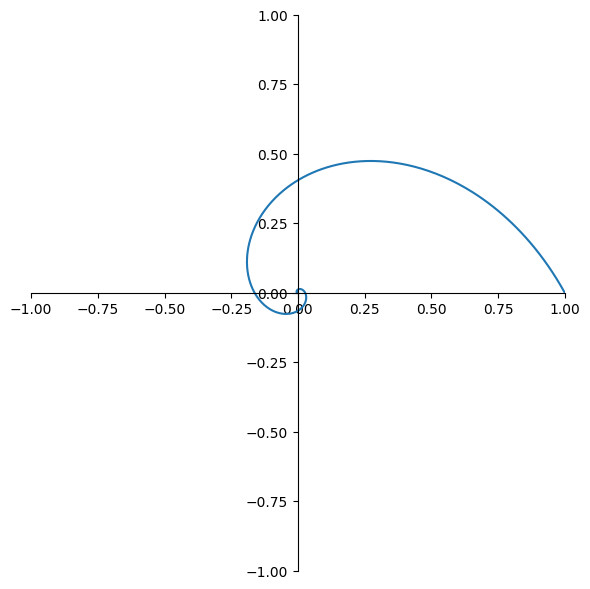

In [46]:
n = 6
a = 2 * pi / n
R = dsol.rhs.subs(alpha, a)
X = R * cos(phi)
Y = R * sin(phi)
phi_max = 4 * pi
p1 = plot_parametric((X, Y), (phi, 0, phi_max),
                      xlim=(-1, 1), ylim=(-1, 1),
                      size=(6, 6), show=False)
p1.show()

**11.** Построим на одном графике траектории всех $n$ жуков.

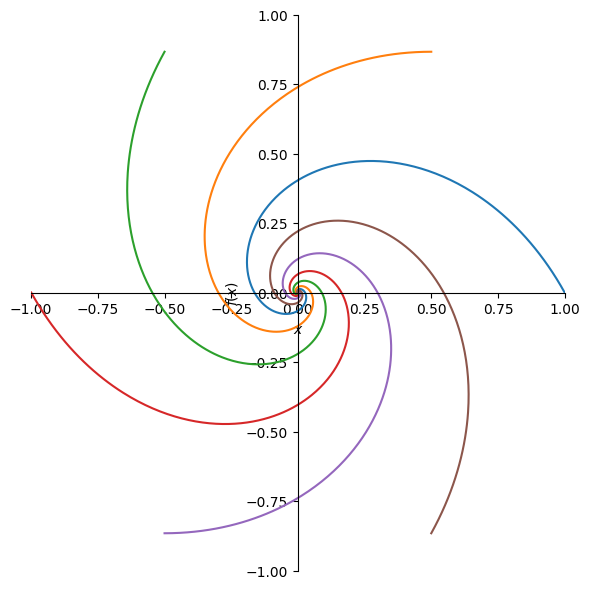

In [47]:
p2 = plot(xlim=(-1, 1), ylim=(-1, 1),
          size=(6, 6), show=False)
for k in range(n):
    R2 = R.subs(phi, phi - k * a)
    X = R2 * cos(phi)
    Y = R2 * sin(phi)
    phi1, phi2 = k * a, k * a + phi_max
    p = plot_parametric((X, Y), (phi, phi1, phi2), show=False)
    p2.extend(p)
p2.show()